# Wpływ zmiany dropoutu na model CNN na zbiorze CIFAR-10

Celem eksperymentu jest proste porównanie dwóch wariantów tego samego modelu:

- dropout wyłączony
- dropout włączony

Nie wykorzystujemy zewnętrznych obrazów. Wynik jest oceniany na zbiorze testowym CIFAR-10.

In [1]:
import adom_library as adom
import pandas as pd
import matplotlib.pyplot as plt

adom.show_device()

cuda


## Parametry eksperymentu

Wartość `dropout_value = None` oznacza w tej bibliotece wyłączenie dropout, ponieważ funkcja `set_dropout` zamienia warstwy dropout na `Identity`.


In [2]:
MODEL_TYPE = "VGG16"
EPOCHS = 10
BATCH_SIZE = 64

DROPOUT_OFF = None
DROPOUT_ON = 0.3

## Wczytanie CIFAR-10

Używamy zbioru treningowego do uczenia oraz zbioru testowego do końcowej oceny.

In [3]:
train_dataset = adom.get_CIFAR10_dataset(train_dataset=True)
test_dataset = adom.get_CIFAR10_dataset(train_dataset=False)

classes = train_dataset.classes

print("Liczba klas:", len(classes))
print("Klasy:", classes)
print("Liczba obrazów treningowych:", len(train_dataset))
print("Liczba obrazów testowych:", len(test_dataset))

Files already downloaded and verified


d:\Projekty\Studia\ADOM\ADOM_2026L_Deep_CNN-VGG\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Liczba klas: 10
Klasy: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Liczba obrazów treningowych: 50000
Liczba obrazów testowych: 10000


## Trening modelu bez dropout

In [4]:
model_without_dropout = adom.train_new_model(
    train_dataset=train_dataset,
    model_type=MODEL_TYPE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    dropout_value=DROPOUT_OFF,
)

adom.save_model(model=model_without_dropout, model_name="dropout-model_without_dropout", classes=classes)

Training VGG for 10 epochs...
Epoch 1, Loss: 1.4617, Acc: 46.87%, Time: 244.77s
Epoch 2, Loss: 0.8636, Acc: 69.78%, Time: 244.30s
Epoch 3, Loss: 0.5374, Acc: 81.45%, Time: 244.27s
Epoch 4, Loss: 0.2458, Acc: 91.64%, Time: 244.14s
Epoch 5, Loss: 0.0995, Acc: 96.68%, Time: 244.61s
Epoch 6, Loss: 0.0691, Acc: 97.70%, Time: 244.56s
Epoch 7, Loss: 0.0499, Acc: 98.38%, Time: 244.43s
Epoch 8, Loss: 0.0478, Acc: 98.44%, Time: 244.81s
Epoch 9, Loss: 0.0366, Acc: 98.79%, Time: 244.80s
Epoch 10, Loss: 0.0366, Acc: 98.84%, Time: 244.34s
Total training time: 2445.03s


## Trening modelu z dropout

In [5]:
model_with_dropout = adom.train_new_model(
    train_dataset=train_dataset,
    model_type=MODEL_TYPE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    dropout_value=DROPOUT_ON,
)

adom.save_model(model=model_with_dropout, model_name="dropout-model_with_dropout", classes=classes)

Training VGG for 10 epochs...
Epoch 1, Loss: 1.4976, Acc: 45.03%, Time: 245.23s
Epoch 2, Loss: 0.9077, Acc: 68.14%, Time: 245.20s
Epoch 3, Loss: 0.5999, Acc: 79.26%, Time: 244.57s
Epoch 4, Loss: 0.3593, Acc: 87.66%, Time: 244.83s
Epoch 5, Loss: 0.1677, Acc: 94.29%, Time: 245.38s
Epoch 6, Loss: 0.1023, Acc: 96.52%, Time: 244.80s
Epoch 7, Loss: 0.0695, Acc: 97.64%, Time: 244.96s
Epoch 8, Loss: 0.0600, Acc: 98.04%, Time: 245.07s
Epoch 9, Loss: 0.0507, Acc: 98.28%, Time: 244.80s
Epoch 10, Loss: 0.0410, Acc: 98.72%, Time: 244.78s
Total training time: 2449.62s


## Ewaluacja modeli na CIFAR-10

Najważniejsza metryka do porównania wpływu dropout to **test accuracy**, ponieważ pokazuje skuteczność modelu na danych niewidzianych podczas treningu.

In [6]:
train_result_without_dropout = adom.evaluate_model_on_dataset(
    model_without_dropout,
    train_dataset,
    classes,
    batch_size=64,
)

test_result_without_dropout = adom.evaluate_model_on_dataset(
    model_without_dropout,
    test_dataset,
    classes,
    batch_size=64,
)

train_result_with_dropout = adom.evaluate_model_on_dataset(
    model_with_dropout,
    train_dataset,
    classes,
    batch_size=64,
)

test_result_with_dropout = adom.evaluate_model_on_dataset(
    model_with_dropout,
    test_dataset,
    classes,
    batch_size=64,
)

## Wyniki

In [7]:
results = [
    {
        "wariant": "dropout wyłączony",
        "dropout_value": "None",
        "train_accuracy_percent": train_result_without_dropout["accuracy_percent"],
        "test_accuracy_percent": test_result_without_dropout["accuracy_percent"],
        "train_loss": train_result_without_dropout["avg_loss"],
        "test_loss": test_result_without_dropout["avg_loss"],
        "parameters": adom.count_model_params(model_without_dropout),
    },
    {
        "wariant": "dropout włączony",
        "dropout_value": DROPOUT_ON,
        "train_accuracy_percent": train_result_with_dropout["accuracy_percent"],
        "test_accuracy_percent": test_result_with_dropout["accuracy_percent"],
        "train_loss": train_result_with_dropout["avg_loss"],
        "test_loss": test_result_with_dropout["avg_loss"],
        "parameters": adom.count_model_params(model_with_dropout),
    },
]

results_df = pd.DataFrame(results)
results_df

,wariant,dropout_value,train_accuracy_percent,test_accuracy_percent,train_loss,test_loss,parameters
0,dropout wyłączony,None,99.354,77.28,0.019679,1.284279,134301514
1,dropout włączony,0.3,99.428,78.14,0.019326,1.118807,134301514


## Wykres porównawczy

Powinniśmy zaobserwować, że dokładność na zbiorze treningowym spadła po zastosowaniu dropout, co jest spodziewane, ponieważ model jest mniej dopasowany do danych treningowych. Jednak dokładność na zbiorze testowym może być wyższa z powodu lepszej generalizacji, co jest głównym celem stosowania dropoutu.

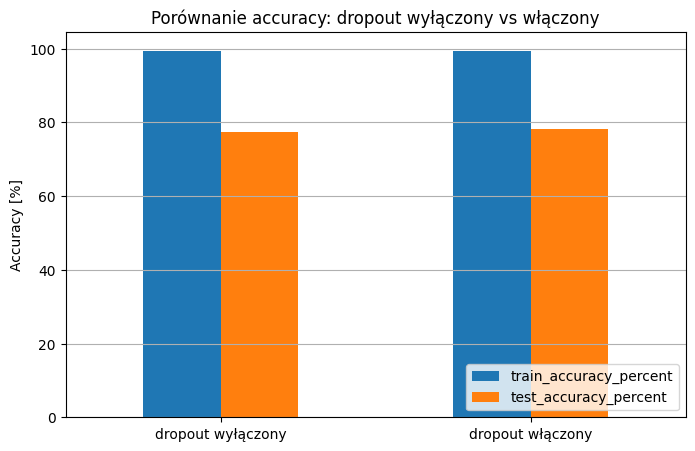

In [8]:
plot_df = results_df.set_index("wariant")[[
    "train_accuracy_percent",
    "test_accuracy_percent",
]]

ax = plot_df.plot(kind="bar", figsize=(8, 5))
ax.set_title("Porównanie accuracy: dropout wyłączony vs włączony")
ax.set_ylabel("Accuracy [%]")
ax.set_xlabel("")
ax.grid(axis="y")
ax.legend(loc="lower right")

plt.xticks(rotation=0)
plt.show()

## Różnica między wynikiem treningowym i testowym

Ta różnica pomaga zauważyć, czy model mocno dopasowuje się do zbioru treningowego. Większa różnica między `train_accuracy` i `test_accuracy` może sugerować większe przeuczenie modelu.

In [9]:
results_df["accuracy_gap_train_minus_test"] = (
    results_df["train_accuracy_percent"] - results_df["test_accuracy_percent"]
)

results_df[[
    "wariant",
    "dropout_value",
    "train_accuracy_percent",
    "test_accuracy_percent",
    "accuracy_gap_train_minus_test",
]]

,wariant,dropout_value,train_accuracy_percent,test_accuracy_percent,accuracy_gap_train_minus_test
0,dropout wyłączony,None,99.354,77.28,22.074
1,dropout włączony,0.3,99.428,78.14,21.288


## Podsumowanie

W eksperymencie porównano dwa warianty tego samego modelu CNN uczonego na zbiorze CIFAR-10. Pierwszy wariant miał dropout wyłączony, natomiast drugi wariant wykorzystywał dropout o zadanej wartości. Oba modele trenowano przez taką samą liczbę epok, z tym samym optymalizatorem oraz na tym samym zbiorze danych.

Celem eksperymentu było sprawdzenie, czy zastosowanie dropout poprawia generalizację modelu (czyli wynik osiągany na danych testowych). Porównano dokładność na zbiorze treningowym oraz testowym. Szczególną uwagę zwrócono na różnicę między dokładnością treningową i testową, ponieważ może ona wskazywać na stopień przeuczenia modelu.

Jeżeli model z dropout osiąga niższy wynik treningowy, ale podobny lub lepszy wynik testowy, może to oznaczać, że dropout ogranicza przeuczenie.
